In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import fsolve
from functools import partial
from matplotlib.lines import Line2D

# used to import local files
import sys  
sys.path.insert(1, '/cluster/tufts/mggg/cdonna01/EC_paper/refactored_2_bloc_stv')

from BT_coh_to_fpv import *

def upper_cone_optimize(data, upper = 1000.0, lower = 0.0, precision = 1, data_total = .95, point_on_line = (.5,.5), xlim = .53):
    """
    Find the minimal slope line going through .5,.5 such that data_total percent of data lies below
    the line.

    Upper: the initial slope of the upper bound line
    Lower: the initial slope of the lower bound line.
    Precision: to what distance do we want the upper and lower bound to match.
    data_total: what percent of data should lie below the line.
    point_on_line: a point that must be on the line.

    return m,b where m is the slope and b is the y-intercept
    """
    target_point_count = int(data_total * len([(x,y) for x,y in data if x >= xlim]))

    proposed_slope = (upper+lower)/2
    b = point_on_line[1]-proposed_slope*point_on_line[0]

    # until we reach desired precision
    while abs(upper-lower) > precision:
        num_contained_points = len([(x,y) for x,y in data if y<= proposed_slope*x+b and x >= xlim])

        # if too few points, we have a new lower bound
        if num_contained_points <= target_point_count:
            lower = proposed_slope
        # if too many points we have a new upper bound
        else:
            upper = proposed_slope
        
        # average the old bounds, compute y intercept
        proposed_slope = (upper+lower)/2
        b = point_on_line[1]-proposed_slope*point_on_line[0]
    
    
    return proposed_slope, b


def lower_cone_optimize(data, upper = 1000.0, lower = -1000.0, precision = 1, data_total = .95, point_on_line = (.5,.5), xlim = .53):
    """
    Find the minimal slope line going through .5,.5 such that data_total percent of data lies above
    the line.

    Upper: the initial slope of the upper bound line
    Lower: the initial slope of the lower bound line.
    Precision: to what distance do we want the upper and lower bound to match.
    data_total: what percent of data should lie above the line.
    point_on_line: a point that must be on the line.

    return m,b where m is the slope and b is the y-intercept
    """
    target_point_count = int(data_total * len([(x,y) for x,y in data if x >= xlim]))
    # print("target", target_point_count)

    proposed_slope = (upper+lower)/2
    b = point_on_line[1]-proposed_slope*point_on_line[0]

    # until we reach desired precision
    while abs(upper-lower) > precision:
        num_contained_points = len([(x,y) for x,y in data if y>= proposed_slope*x+b and x >= xlim])
        # print("num_contained", num_contained_points)

        # if too few points, we have a new upper bound
        if num_contained_points <= target_point_count:
            upper = proposed_slope
        # if too many points we have a new lower bound
        else:
            lower = proposed_slope
        
        # average the old bounds, compute y intercept
        proposed_slope = (upper+lower)/2
        b = point_on_line[1]-proposed_slope*point_on_line[0]
    
    
    return proposed_slope, b


In [3]:
fpv_bs = [round(x, 2) for x in np.arange(0.5, .99, 0.05)]
fpv_as = [round(x, 2) for x in np.arange(0.5, .99, 0.05)]
b_prop_list = [x/100 for x in range(5, 100, 10)]

generators=["slate-CS-C", "slate-CS-W", "slate-BT", "slate-PL"]
colors= {"slate-CS-C":'#E32636',
        "slate-CS-W":'#FB607F',
         "slate-BT":'#8DB600',
         "slate-PL":'#FFBF00'}

pi_types_fixed=["UU", "UX", "XX-same", "XX-dif"]
pi_types_dirichlet=["U", "XA", "XB", "BX", "AX", "X"]

fixed_markers = {"UU":"o", 
"UX":"v", 
"XX-same":"d",
"XX-dif":"s"}

dirichlet_markers = {"U":"o", 
"XA":"v", 
"XB":"^",
"BX":"s",
"AX": "d",
"X": "P"}

# Fixed intervals

In [4]:
N_TRIALS = 25
N_BALLOTS = 1000
N_SEATS = 6
N_CANDS_PER_BLOC = 6


election_path_name = f'EC_paper/refactored_2_bloc_stv/election_results/2_bloc/fixed_intervals/trials_{N_TRIALS}_ballots_{N_BALLOTS}_seats_{N_SEATS}_cperbloc_{N_CANDS_PER_BLOC}'


In [5]:
fixed_dfs = {}

for fpv_b in fpv_bs:
    # for g in generators:
    for g in ["slate-BT"]:
        for pi_type in pi_types_fixed:
            for b_prop in b_prop_list:
                for fpv_a in fpv_as:
                    try:
                        df = pd.read_csv(f"{election_path_name}/fpv_b_{fpv_b}_fpv_a_{fpv_a}_b_prop_{b_prop}_{g}_pi_type_{pi_type}/fpv_b_{fpv_b}_fpv_a_{fpv_a}_b_prop_{b_prop}_{g}_pi_type_{pi_type}.csv", index_col=0)
                        fixed_dfs[(fpv_b, g, pi_type, b_prop, fpv_a)] = df
                    except:
                        print(fpv_b, fpv_a, b_prop, g, pi_type)
                    




0.5 0.7 0.05 slate-BT UU
0.5 0.75 0.05 slate-BT UU
0.5 0.8 0.05 slate-BT UU
0.5 0.85 0.05 slate-BT UU
0.5 0.9 0.05 slate-BT UU
0.5 0.95 0.05 slate-BT UU
0.5 0.7 0.15 slate-BT UU
0.5 0.75 0.15 slate-BT UU
0.5 0.8 0.15 slate-BT UU
0.5 0.85 0.15 slate-BT UU
0.5 0.9 0.15 slate-BT UU
0.5 0.95 0.15 slate-BT UU
0.5 0.7 0.25 slate-BT UU
0.5 0.75 0.25 slate-BT UU
0.5 0.8 0.25 slate-BT UU
0.5 0.85 0.25 slate-BT UU
0.5 0.9 0.25 slate-BT UU
0.5 0.95 0.25 slate-BT UU
0.5 0.7 0.35 slate-BT UU
0.5 0.75 0.35 slate-BT UU
0.5 0.8 0.35 slate-BT UU
0.5 0.85 0.35 slate-BT UU
0.5 0.9 0.35 slate-BT UU
0.5 0.95 0.35 slate-BT UU
0.5 0.7 0.45 slate-BT UU
0.5 0.75 0.45 slate-BT UU
0.5 0.8 0.45 slate-BT UU
0.5 0.85 0.45 slate-BT UU
0.5 0.9 0.45 slate-BT UU
0.5 0.95 0.45 slate-BT UU
0.5 0.7 0.55 slate-BT UU
0.5 0.75 0.55 slate-BT UU
0.5 0.8 0.55 slate-BT UU
0.5 0.85 0.55 slate-BT UU
0.5 0.9 0.55 slate-BT UU
0.5 0.95 0.55 slate-BT UU
0.5 0.7 0.65 slate-BT UU
0.5 0.75 0.65 slate-BT UU
0.5 0.8 0.65 slate-BT UU
0.5 0.

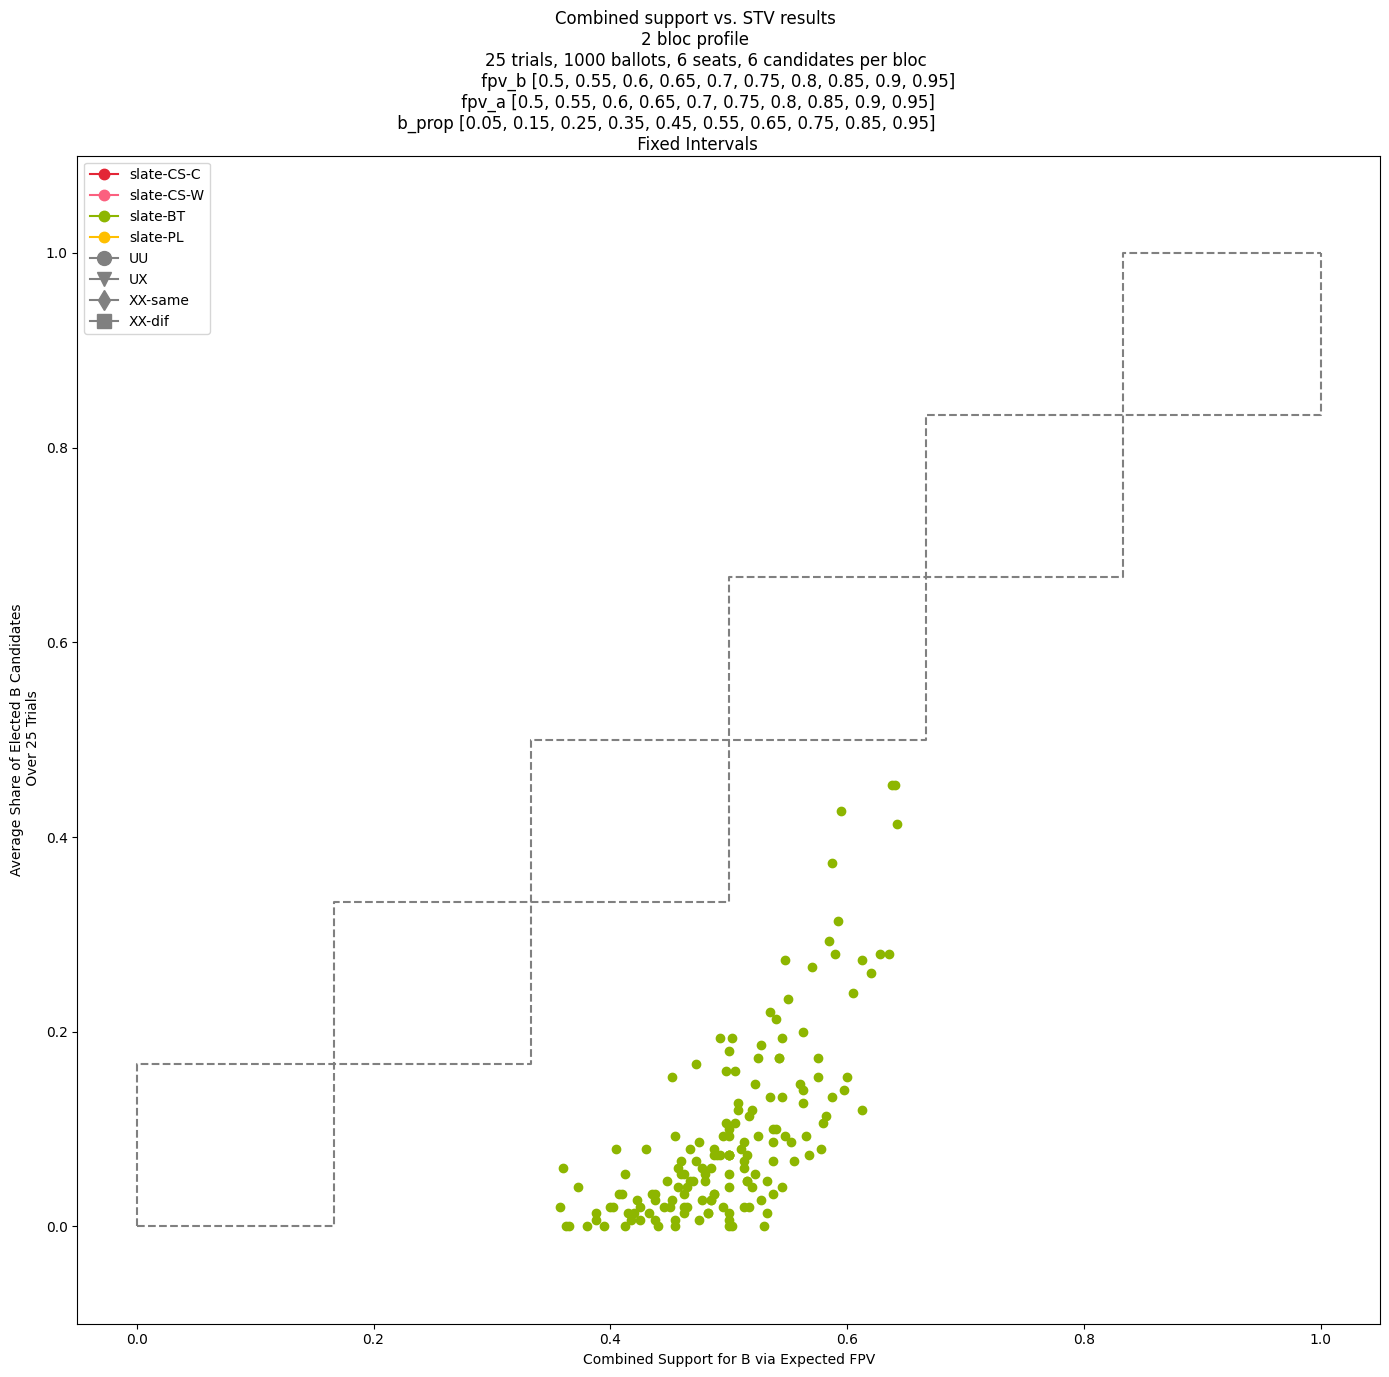

In [7]:
fpv_bs = [round(x, 2) for x in np.arange(0.5, .99, 0.05)]
fpv_as = [round(x, 2) for x in np.arange(0.5, .99, 0.05)]
b_prop_list = [x/100 for x in range(5, 100, 10)]


LINES = False

# STAT = f"avg borda share for B cands Over {N_TRIALS} Trials"
# STAT = f"avg fpv for B cands Over {N_TRIALS} Trials"
STAT = "Expected FPV"

fig, ax = plt.subplots(figsize=(14,14))
ax.step(
    np.linspace(0,1,N_SEATS+1),
    np.arange(0,1.1, 1/N_SEATS),
    linestyle = 'dashed',
    c='gray',
    where='pre'
)
ax.step(
    np.linspace(0,1,N_SEATS+1),
    np.arange(0,1.1, 1/N_SEATS),
    linestyle = 'dashed',
    c='gray',
    where='post'
)
ax.set_ylabel(f'Average Share of Elected B Candidates\n Over {N_TRIALS} Trials')
ax.set_xlabel(f'Combined Support for B via {STAT}')

data  = []
# for g in generators:
for g in ["slate-BT"]:
    for b_prop in b_prop_list:
        for pi_type in ["UU"]:
        # for pi_type in pi_types_fixed:
            for fpv_b in fpv_bs:
                for fpv_a in fpv_as:
                    try:
                        df = fixed_dfs[(fpv_b, g, pi_type, b_prop, fpv_a)]
                        
                        # combined support
                        if "borda" in STAT:
                            x=np.average(df["B Borda shares"])

                        elif "observed avg fpv" in STAT:
                            x=np.average(df["B fpv"])
                        
                        else:
                            x = fpv_b*b_prop  + (1-fpv_a)*(1-b_prop)
                        
                        # average seats over trials
                        y = np.average(df["B cands elected"])/N_SEATS 

                        data.append((x,y))
                        if True:
                            ax.scatter(x, y,
                                label=g,
                                marker = fixed_markers[pi_type],
                                edgecolor=colors[g], 
                                facecolor=colors[g]
                            )
                            # ax.text(x,y, s=str((p, b_prop, a_coh)))
                    except:
                        pass

if LINES:
    x = np.linspace(0, 1, 100)  
    m_1,b_1 = upper_cone_optimize(data, 
                upper = 1000.0, 
                lower = -1000.0, 
                precision = .01, 
                data_total = .95, 
                point_on_line = (.5, .5), 
                xlim = .53)
    y = m_1*x+b_1
    plt.plot(x,y, label = f"upper cone {m_1:.2f}x+{b_1:.2f}", color="red")

    m_2,b_2 = lower_cone_optimize(data, 
                upper = 1000.0, 
                lower = -1000.0, 
                precision = .01, 
                data_total = .95, 
                point_on_line = (.5, .5), 
                xlim = .53)
    y = m_2*x+b_2
    plt.plot(x,y, label = f"lower cone {m_2:.2f}x+{b_2:.2f}", color="blue")

    # line of best fit
    x,y = zip(*data)
    m_3=np.polyfit(x, y, 1)[0]
    b_3=np.polyfit(x, y, 1)[1]
    plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)), color="green", ls="dashed", label=f"LOBF {m_3:.2f}x+{b_3:.2f}")


legend_elements = [
    Line2D([0], [0], marker='.', color=colors[g], label=g, markersize=15)
    for g in generators
] + [Line2D([0], [0], marker=fixed_markers[pi_type], color="grey", label=pi_type, markersize=10)
    for pi_type in pi_types_fixed] 

if LINES:
    legend_elements += [Line2D([0], [0], color="red", label = f"upper cone {m_1:.2f}x+{b_1:.2f}")
    ] + \
    [Line2D([0], [0], color="blue", label = f"lower cone {m_2:.2f}x+{b_2:.2f}")]+ \
    [Line2D([0], [0], color="green", ls="dashed", label=f"LOBF {m_3:.2f}x+{b_3:.2f}")]


plt.ylim(-.1, 1.1)
plt.legend(handles=legend_elements)
plt.suptitle(f"Combined support vs. STV results\n2 bloc profile\n\
    {N_TRIALS} trials, {N_BALLOTS} ballots, {N_SEATS} seats, {N_CANDS_PER_BLOC} candidates per bloc\n\
         fpv_b {fpv_bs}\n fpv_a {fpv_as}\n b_prop {b_prop_list}\
            \n Fixed Intervals")
plt.tight_layout()
plt.show()
# plt.savefig(f"EC_paper/refactored_2_bloc_stv/figures/2_bloc/fixed_intervals/{N_SEATS}_seats_combined_support_STV.pdf")

# Checking slopes

In [8]:
slopes = {"generator":[],
            "pi_type":[],
            "cohesion":[],
            "UC m":[],
            "UC b": [],
            "LC m":[],
            "LC b": [],
            "LOBF m":[],
            "LOBF b": [],}

STAT = f"avg borda share for B cands Over {N_TRIALS} Trials"
# STAT = f"avg fpv for B cands Over {N_TRIALS} Trials"
# STAT = "Expected FPV"

for g in generators:
# for g in ["slate-PL"]:
    for pi_type in pi_types_fixed:
        for cohesion in ["full", "polarized"]:
            print(g, pi_type, f"cohesion {cohesion}")
            slopes["generator"].append(g)
            slopes["pi_type"].append(pi_type)
            slopes["cohesion"].append(cohesion)

            if cohesion == "full":
                fpv_bs = [round(x, 2) for x in np.arange(0.55, .99, 0.05)]
                fpv_as = [round(x, 2) for x in np.arange(0.55, .99, 0.05)]
            else:
                fpv_bs = [round(x, 2) for x in np.arange(0.7, .99, 0.05)]
                fpv_as = [round(x, 2) for x in np.arange(0.7, .99, 0.05)]


            b_prop_list = [x/100 for x in range(5, 100, 10)]

            for lines in [True, False]:
                fig, ax = plt.subplots(figsize=(14,14))
                ax.step(
                    np.linspace(0,1,N_SEATS+1),
                    np.arange(0,1.1, 1/N_SEATS),
                    linestyle = 'dashed',
                    c='gray',
                    where='pre'
                )
                ax.step(
                    np.linspace(0,1,N_SEATS+1),
                    np.arange(0,1.1, 1/N_SEATS),
                    linestyle = 'dashed',
                    c='gray',
                    where='post'
                )
                ax.set_ylabel(f'Average Share of Elected B Candidates\n Over {N_TRIALS} Trials')
                ax.set_xlabel(f'Combined Support for B via {STAT}')
            
                data  = []
                for b_prop in b_prop_list:
                    for fpv_b in fpv_bs:
                        for fpv_a in fpv_as:
                            df = fixed_dfs[(fpv_b, g, pi_type, b_prop, fpv_a)]
                            # combined support
                            if "borda" in STAT:
                                x=np.average(df["B Borda shares"])
                            elif "observed avg fpv" in STAT:
                                x=np.average(df["B fpv"])
                            else:
                                x = fpv_b*b_prop  + (1-fpv_a)*(1-b_prop)
                            
                            # average seats over trials
                            y = np.average(df["B cands elected"])/N_SEATS 

                            data.append((x,y))
                            ax.scatter(x, y,
                            label=g,
                            marker = fixed_markers[pi_type],
                            edgecolor=colors[g], 
                            facecolor=colors[g]
                        )
                        
                        

            
                if lines:                
                    x = np.linspace(0, 1, 100)  
                    m_1,b_1 = upper_cone_optimize(data, 
                                upper = 1000.0, 
                                lower = -1000.0, 
                                precision = .01, 
                                data_total = .95, 
                                point_on_line = (.5, .5), 
                                xlim = .53)
                    y = m_1*x+b_1
                    plt.plot(x,y, label = f"upper cone {m_1:.2f}x+{b_1:.2f}", color="red")
                    print(f"upper cone {m_1:.2f}x+{b_1:.2f}")
                    slopes["UC m"].append(m_1)
                    slopes["UC b"].append(b_1)

                    # print("lower cone")
                    m_2,b_2 = lower_cone_optimize(data, 
                                upper = 1000.0, 
                                lower = -1000.0, 
                                precision = .01, 
                                data_total = .95, 
                                point_on_line = (.5, .5), 
                                xlim = .53)
                    y = m_2*x+b_2
                    plt.plot(x,y, label = f"lower cone {m_2:.2f}x+{b_2:.2f}", color="blue")

                    print(f"lower cone {m_2:.2f}x+{b_2:.2f}")
                    slopes["LC m"].append(m_2)
                    slopes["LC b"].append(b_2)

                    # line of best fit
                    x,y = zip(*data)
                    m_3=np.polyfit(x, y, 1)[0]
                    b_3=np.polyfit(x, y, 1)[1]
                    plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)), color="green", ls="dashed", label=f"LOBF {m_3:.2f}x+{b_3:.2f}")

                    print(f"LOBF {m_3:.2f}x+{b_3:.2f}\n")
                    slopes["LOBF m"].append(m_3)
                    slopes["LOBF b"].append(b_3)

                    legend_elements = [
                        Line2D([0], [0], marker='.', color=colors[g], label=g, markersize=15)
                        for g in [g]
                    ] + [Line2D([0], [0], marker=fixed_markers[pi_type], color="grey", label=pi_type, markersize=10)
                        for pi_type in [pi_type]] +\
                        [Line2D([0], [0], color="red", label = f"upper cone {m_1:.2f}x+{b_1:.2f}")
                        ] + \
                        [Line2D([0], [0], color="blue", label = f"lower cone {m_2:.2f}x+{b_2:.2f}")]+ \
                        [Line2D([0], [0], color="green", ls="dashed", label=f"LOBF {m_3:.2f}x+{b_3:.2f}")]
                else:
                    legend_elements = [
                        Line2D([0], [0], marker='.', color=colors[g], label=g, markersize=15)
                        for g in [g]
                    ] + [Line2D([0], [0], marker=fixed_markers[pi_type], color="grey", label=pi_type, markersize=10)
                        for pi_type in [pi_type]]

                plt.ylim(-.1, 1.1)
                plt.legend(handles=legend_elements)
                plt.suptitle(f"Combined support vs. STV results\n2 bloc profile\n{N_TRIALS} trials, {N_BALLOTS} ballots, {N_SEATS} seats, {N_CANDS_PER_BLOC} candidates per bloc\n fpv_bs {fpv_bs}\n fpv_as {fpv_as}\n b_prop {b_prop_list}\n Fixed Intervals")
                plt.tight_layout()
                # plt.show()

                if lines:
                    plt.savefig(f"EC_paper/refactored_2_bloc_stv/figures/2_bloc/fixed_intervals/line_fit/{N_SEATS}_seats_{STAT}_combined_support_STV_{g}_{pi_type}_{cohesion}.pdf")
                else:
                    plt.savefig(f"EC_paper/refactored_2_bloc_stv/figures/2_bloc/fixed_intervals/{N_SEATS}_seats_{STAT}_combined_support_STV_{g}_{pi_type}_{cohesion}.pdf")
                
                plt.close()
        
    
    

data_frame = pd.DataFrame.from_dict(slopes)
data_frame.to_csv(f"EC_paper/refactored_2_bloc_stv/slope_data/fixed_intervals/{N_SEATS}_seats_slopes_2_bloc_stv_{STAT}.csv")

slate-CS-C UU cohesion full
upper cone 2.57x+-0.78
lower cone 0.00x+0.50
LOBF 1.98x+-0.57

slate-CS-C UU cohesion polarized
upper cone 2.57x+-0.79
lower cone 0.45x+0.28
LOBF 1.93x+-0.53

slate-CS-C UX cohesion full
upper cone 0.80x+0.10
lower cone -8.76x+4.88
LOBF 0.82x+-0.18

slate-CS-C UX cohesion polarized
upper cone 0.79x+0.11
lower cone -7.85x+4.42
LOBF 0.78x+-0.16

slate-CS-C XX-same cohesion full
upper cone 0.65x+0.17
lower cone -8.89x+4.95
LOBF 0.56x+-0.07

slate-CS-C XX-same cohesion polarized
upper cone 0.68x+0.16
lower cone -7.85x+4.42
LOBF 0.58x+-0.06

slate-CS-C XX-dif cohesion full
upper cone 0.68x+0.16
lower cone -6.53x+3.77
LOBF 0.70x+-0.07

slate-CS-C XX-dif cohesion polarized
upper cone 0.71x+0.15
lower cone -5.15x+3.07
LOBF 0.71x+-0.07

slate-CS-W UU cohesion full
upper cone 7.66x+-3.33
lower cone 1.38x+-0.19
LOBF 1.98x+-0.42

slate-CS-W UU cohesion polarized
upper cone 6.90x+-2.95
lower cone 1.37x+-0.18
LOBF 1.93x+-0.41

slate-CS-W UX cohesion full
upper cone 2.31x+